# Desafio Técnico Trainee — Bemol Serviços Financeiros

**Objetivo geral:** entregar insights que ajudem a Product Manager a **aumentar a adoção da Recarga Digital** e **reter clientes do Vale Pré-pago no ecossistema digital**.

**Roteiro do notebook**
1. Setup e carga dos dados
2. Tratamento e qualidade (ADA)
3. Métricas-chave por produto (transações, valor total, ticket médio)
4. Churn e retenção mensal por produto
5. Evolução mensal de adoção
6. Segmentação: nível, loja, cidade
7. Visualizações comparativas e tabela-resumo
8. Conclusões e recomendações para a PM

## 1. Setup e carga

In [1]:
# 1.1 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titleweight'] = 'bold'

# Paleta fixa por produto (consistência entre gráficos)
CORES = {'VALE_PRE_PAGO': '#1f77b4', 'RECARGA_DIGITAL': '#d62728'}

In [2]:
# 1.2 Leitura robusta — detecta o formato pelos BYTES iniciais (ignora extensão)
# Funciona se o arquivo for XLSX real OU CSV (independente de estar nomeado .xlsx ou .csv)
from pathlib import Path

def ler_base(caminho):
    p = Path(caminho)
    with open(p, 'rb') as f:
        magic = f.read(4)

    # XLSX real começa com PK\x03\x04 (assinatura zip)
    if magic == b'PK\x03\x04':
        return pd.read_excel(p, engine='openpyxl')

    # Caso contrário, tenta CSV com diferentes separadores e encodings
    for sep in (',', ';', '\t', '|'):
        for enc in ('utf-8', 'latin-1'):
            try:
                df = pd.read_csv(p, sep=sep, encoding=enc)
                if df.shape[1] >= 2:
                    return df
            except Exception:
                continue
    raise ValueError(f'Formato não reconhecido: {caminho}')

# Ajuste os caminhos abaixo se necessário (.xlsx ou .csv, tanto faz — a função detecta sozinha)
clientes = ler_base('base_clientes_desafio.xlsx')
transacoes = ler_base('base_transacoes_desafio.xlsx')

print('clientes  :', clientes.shape, '| colunas:', list(clientes.columns))
print('transacoes:', transacoes.shape, '| colunas:', list(transacoes.columns))
clientes.head()

clientes  : (182464, 1) | colunas: ['ID_PESSOA,NIVEL_CLIENTE,DATA_ALTERACAO_NIVEL,CIDADE']
transacoes: (845249, 1) | colunas: ['DATA,ID_PESSOA,PRODUTO,NUM_LOJA,VALOR_TRANSACAO']


,"ID_PESSOA,NIVEL_CLIENTE,DATA_ALTERACAO_NIVEL,CIDADE"
0,"2031800,5,2022-08-21,MANAUS"
1,"2110260,5,2021-05-19,MANAUS"
2,"2790720,4,2024-01-13,MANAUS"
3,"2940210,5,2018-08-01,MANAUS"
4,"10040230,5,2025-04-18,MANAUS"


In [3]:
clientes.head()

,"ID_PESSOA,NIVEL_CLIENTE,DATA_ALTERACAO_NIVEL,CIDADE"
0,"2031800,5,2022-08-21,MANAUS"
1,"2110260,5,2021-05-19,MANAUS"
2,"2790720,4,2024-01-13,MANAUS"
3,"2940210,5,2018-08-01,MANAUS"
4,"10040230,5,2025-04-18,MANAUS"


In [4]:
# Corrige DataFrames com uma unica coluna (CSV salvo dentro do XLSX)
def _fix_single_col(df):
    if df.shape[1] == 1:
        col = df.columns[0]
        for sep in (',', ';', '|'):
            if sep in col:
                cols = col.split(sep)
                df = df[col].str.split(sep, expand=True)
                df.columns = cols
                return df
    return df

clientes = _fix_single_col(clientes)
transacoes = _fix_single_col(transacoes)
print('clientes :', clientes.shape, '| colunas:', list(clientes.columns))
print('transacoes:', transacoes.shape, '| colunas:', list(transacoes.columns))
clientes.head()

clientes : (182464, 4) | colunas: ['ID_PESSOA', 'NIVEL_CLIENTE', 'DATA_ALTERACAO_NIVEL', 'CIDADE']
transacoes: (845249, 5) | colunas: ['DATA', 'ID_PESSOA', 'PRODUTO', 'NUM_LOJA', 'VALOR_TRANSACAO']


,ID_PESSOA,NIVEL_CLIENTE,DATA_ALTERACAO_NIVEL,CIDADE
0,2031800,5,2022-08-21,MANAUS
1,2110260,5,2021-05-19,MANAUS
2,2790720,4,2024-01-13,MANAUS
3,2940210,5,2018-08-01,MANAUS
4,10040230,5,2025-04-18,MANAUS


In [5]:
transacoes.head()

,DATA,ID_PESSOA,PRODUTO,NUM_LOJA,VALOR_TRANSACAO
0,2023-03-31,1640,VALE_PRE_PAGO,53.0,66.95
1,2023-03-31,5900,VALE_PRE_PAGO,53.0,93.268
2,2022-06-17,5900,VALE_PRE_PAGO,53.0,32.8
3,2023-07-26,9080,VALE_PRE_PAGO,285.0,1.902
4,2023-08-03,9080,VALE_PRE_PAGO,55.0,34.802


## 2. Tratamento e qualidade dos dados (ADA)

Conferências feitas aqui:
- tipos das colunas (datas, numéricos, categóricos);
- nulos e duplicados;
- consistência das categorias (produto, cidade, nível);
- valores negativos ou zero em `VALOR_TRANSACAO`;
- integridade referencial entre `transacoes.ID_PESSOA` e `clientes.ID_PESSOA`.

In [6]:
# 2.1 Tipos e nulos
print('--- CLIENTES ---')
print(clientes.dtypes)
print('\nNulos:')
print(clientes.isna().sum())
print('\nDuplicados ID_PESSOA:', clientes['ID_PESSOA'].duplicated().sum())

print('\n--- TRANSACOES ---')
print(transacoes.dtypes)
print('\nNulos:')
print(transacoes.isna().sum())

--- CLIENTES ---
ID_PESSOA               object
NIVEL_CLIENTE           object
DATA_ALTERACAO_NIVEL    object
CIDADE                  object
dtype: object

Nulos:
ID_PESSOA               0
NIVEL_CLIENTE           0
DATA_ALTERACAO_NIVEL    0
CIDADE                  0
dtype: int64

Duplicados ID_PESSOA: 0

--- TRANSACOES ---
DATA               object
ID_PESSOA          object
PRODUTO            object
NUM_LOJA           object
VALOR_TRANSACAO    object
dtype: object

Nulos:
DATA               0
ID_PESSOA          0
PRODUTO            0
NUM_LOJA           0
VALOR_TRANSACAO    0
dtype: int64


In [7]:
# 2.2 Padronização de tipos e colunas auxiliares
clientes['DATA_ALTERACAO_NIVEL'] = pd.to_datetime(clientes['DATA_ALTERACAO_NIVEL'], errors='coerce')
clientes['NIVEL_CLIENTE'] = pd.to_numeric(clientes['NIVEL_CLIENTE'], errors='coerce').astype('Int64')
clientes['CIDADE'] = clientes['CIDADE'].astype(str).str.strip().str.upper()

transacoes['DATA'] = pd.to_datetime(transacoes['DATA'], errors='coerce')
transacoes['VALOR_TRANSACAO'] = pd.to_numeric(transacoes['VALOR_TRANSACAO'], errors='coerce')
transacoes['PRODUTO'] = transacoes['PRODUTO'].astype(str).str.strip().str.upper()
transacoes['NUM_LOJA'] = transacoes['NUM_LOJA'].astype(str).str.strip()

# Remove duplicados por ID_PESSOA, mantendo a alteração de nível mais recente
clientes = (clientes.sort_values('DATA_ALTERACAO_NIVEL')
                    .drop_duplicates('ID_PESSOA', keep='last')
                    .reset_index(drop=True))

# Coluna mês (período mensal) — eixo principal das análises temporais
transacoes['MES'] = transacoes['DATA'].dt.to_period('M')

print('Período coberto:', transacoes['DATA'].min().date(), 'a', transacoes['DATA'].max().date())
print('Produtos:', transacoes['PRODUTO'].unique())
print('Lojas únicas:', transacoes['NUM_LOJA'].nunique())
print('Clientes em transações:', transacoes['ID_PESSOA'].nunique())

Período coberto: 2022-06-01 a 2025-06-30
Produtos: ['VALE_PRE_PAGO' 'RECARGA_DIGITAL' 'RECARGA_DIXITAL' ...
 'RECARGA_DIGITEAL' 'VALE_BRE_PAGO' 'VAZE_PRE_PAGO']
Lojas únicas: 30
Clientes em transações: 182489


In [8]:
# 2.3 Tratamento de valores inválidos
qtd_negativos = (transacoes['VALOR_TRANSACAO'] < 0).sum()
qtd_zeros = (transacoes['VALOR_TRANSACAO'] == 0).sum()
qtd_nulos = transacoes['VALOR_TRANSACAO'].isna().sum()
print(f'Negativos: {qtd_negativos} | Zeros: {qtd_zeros} | Nulos: {qtd_nulos}')

# Decisão: remover registros sem data, sem produto válido ou com valor nulo/negativo.
# Zeros são mantidos (podem ser estornos ou ajustes; sinalizamos mas não excluímos).
produtos_validos = {'VALE_PRE_PAGO', 'RECARGA_DIGITAL'}
antes = len(transacoes)
transacoes = transacoes[
    transacoes['DATA'].notna() &
    transacoes['PRODUTO'].isin(produtos_validos) &
    transacoes['VALOR_TRANSACAO'].notna() &
    (transacoes['VALOR_TRANSACAO'] >= 0)
].copy()
print(f'Linhas removidas: {antes - len(transacoes):,} ({(antes-len(transacoes))/antes:.2%})')

Negativos: 0 | Zeros: 0 | Nulos: 0
Linhas removidas: 8,151 (0.96%)


In [9]:
# 2.4 Integridade referencial e join
ids_orfaos = (~transacoes['ID_PESSOA'].isin(clientes['ID_PESSOA'])).sum()
print(f'Transações sem cliente correspondente: {ids_orfaos:,}')

# left join: mantém todas as transações, NIVEL/CIDADE viram NaN para clientes não cadastrados
df = transacoes.merge(
    clientes[['ID_PESSOA', 'NIVEL_CLIENTE', 'CIDADE']],
    on='ID_PESSOA', how='left'
)
df.head()

Transações sem cliente correspondente: 38


,DATA,ID_PESSOA,PRODUTO,NUM_LOJA,VALOR_TRANSACAO,MES,NIVEL_CLIENTE,CIDADE
0,2023-03-31,1640,VALE_PRE_PAGO,53.0,66.95,2023-03,5,MANAUS
1,2023-03-31,5900,VALE_PRE_PAGO,53.0,93.27,2023-03,5,MANAUS
2,2022-06-17,5900,VALE_PRE_PAGO,53.0,32.80,2022-06,5,MANAUS
3,2023-07-26,9080,VALE_PRE_PAGO,285.0,1.90,2023-07,5,MANAUS
4,2023-08-03,9080,VALE_PRE_PAGO,55.0,34.80,2023-08,5,MANAUS


## 3. Métricas-chave por produto

- **Número de transações**
- **Valor total movimentado**
- **Ticket médio** (valor médio por transação)
- **Clientes únicos** (base ativa total no período)

In [10]:
metricas_produto = df.groupby('PRODUTO').agg(
    num_transacoes=('VALOR_TRANSACAO', 'size'),
    valor_total=('VALOR_TRANSACAO', 'sum'),
    ticket_medio=('VALOR_TRANSACAO', 'mean'),
    clientes_unicos=('ID_PESSOA', 'nunique')
).round(2)

# Acrescenta % de share
metricas_produto['share_transacoes_%'] = (metricas_produto['num_transacoes'] /
                                          metricas_produto['num_transacoes'].sum() * 100).round(1)
metricas_produto['share_valor_%'] = (metricas_produto['valor_total'] /
                                     metricas_produto['valor_total'].sum() * 100).round(1)

metricas_produto

,num_transacoes,valor_total,ticket_medio,clientes_unicos,share_transacoes_%,share_valor_%
PRODUTO,,,,,,
RECARGA_DIGITAL,506469,"99,219,531.09",195.90,47374,60.50,82.00
VALE_PRE_PAGO,330629,"21,831,851.25",66.03,147201,39.50,18.00


## 4. Churn e retenção mensal por produto

**Definições adotadas**
- Um cliente está **ativo no mês M** em um produto se realizou ao menos 1 transação desse produto em M.
- **Retenção(M)** = clientes ativos em M-1 que continuam ativos em M, dividido pelos ativos em M-1.
- **Churn(M)** = 1 − Retenção(M).

Isso é calculado **por produto**, o que permite ver, por exemplo, quem deixou de usar o Vale Pré-pago mês a mês.

In [11]:
def calcular_churn_retencao(transacoes_df, produto):
    """Retorna DataFrame mensal com ativos, retidos, retencao_% e churn_% do produto."""
    sub = transacoes_df[transacoes_df['PRODUTO'] == produto]
    ativos_por_mes = sub.groupby('MES')['ID_PESSOA'].apply(set).sort_index()
    meses = ativos_por_mes.index.tolist()
    linhas = []
    for i, m in enumerate(meses):
        ativos = ativos_por_mes.loc[m]
        if i == 0:
            linhas.append({'MES': m, 'ativos': len(ativos), 'retidos': np.nan,
                           'retencao_%': np.nan, 'churn_%': np.nan})
        else:
            ativos_prev = ativos_por_mes.loc[meses[i-1]]
            retidos = len(ativos & ativos_prev)
            ret = retidos / len(ativos_prev) * 100 if len(ativos_prev) else np.nan
            linhas.append({'MES': m, 'ativos': len(ativos), 'retidos': retidos,
                           'retencao_%': round(ret, 1), 'churn_%': round(100 - ret, 1)})
    return pd.DataFrame(linhas)

churn_vpp = calcular_churn_retencao(df, 'VALE_PRE_PAGO')
churn_rd = calcular_churn_retencao(df, 'RECARGA_DIGITAL')

print('Vale Pré-pago — últimos 6 meses:')
print(churn_vpp.tail(6).to_string(index=False))
print('\nRecarga Digital — últimos 6 meses:')
print(churn_rd.tail(6).to_string(index=False))

Vale Pré-pago — últimos 6 meses:
    MES  ativos  retidos  retencao_%  churn_%
2025-01    1964   359.00       13.60    86.40
2025-02    1795   306.00       15.60    84.40
2025-03    1894   305.00       17.00    83.00
2025-04    1836   288.00       15.20    84.80
2025-05    1880   311.00       16.90    83.10
2025-06    1558   259.00       13.80    86.20

Recarga Digital — últimos 6 meses:
    MES  ativos  retidos  retencao_%  churn_%
2025-01    8603 4,777.00       54.60    45.40
2025-02    8967 4,871.00       56.60    43.40
2025-03    9855 5,239.00       58.40    41.60
2025-04   10029 5,556.00       56.40    43.60
2025-05   10646 5,880.00       58.60    41.40
2025-06   10630 6,095.00       57.30    42.70


In [12]:
# Churn/Retenção média no período (excluindo o primeiro mês que não tem M-1)
resumo_churn = pd.DataFrame({
    'VALE_PRE_PAGO':    [churn_vpp['retencao_%'].mean(), churn_vpp['churn_%'].mean()],
    'RECARGA_DIGITAL':  [churn_rd['retencao_%'].mean(),  churn_rd['churn_%'].mean()]
}, index=['Retenção média mensal (%)', 'Churn médio mensal (%)']).round(1)
resumo_churn

,VALE_PRE_PAGO,RECARGA_DIGITAL
Retenção média mensal (%),17.50,58.00
Churn médio mensal (%),82.50,42.00


## 5. Evolução mensal de adoção

Três visões complementares:
- **Volume de transações** por produto, mês a mês
- **Valor movimentado** por produto, mês a mês
- **Clientes ativos únicos** por produto, mês a mês (proxy mais limpa de adoção)
- **Novos clientes** por produto (primeira transação no produto naquele mês)

In [13]:
evolucao = df.groupby(['MES', 'PRODUTO']).agg(
    num_transacoes=('VALOR_TRANSACAO', 'size'),
    valor_total=('VALOR_TRANSACAO', 'sum'),
    clientes_ativos=('ID_PESSOA', 'nunique')
).reset_index()

# Novos clientes por produto = primeira aparição do par (ID_PESSOA, PRODUTO)
primeira_uso = df.groupby(['ID_PESSOA', 'PRODUTO'])['MES'].min().reset_index()
novos = (primeira_uso.groupby(['MES', 'PRODUTO']).size()
                     .reset_index(name='novos_clientes'))
evolucao = evolucao.merge(novos, on=['MES', 'PRODUTO'], how='left').fillna({'novos_clientes': 0})
evolucao['MES_DT'] = evolucao['MES'].dt.to_timestamp()
evolucao.head()

,MES,PRODUTO,num_transacoes,valor_total,clientes_ativos,novos_clientes,MES_DT
0,2022-06,RECARGA_DIGITAL,3227,"484,458.27",1418,1418,2022-06-01
1,2022-06,VALE_PRE_PAGO,26189,"1,593,451.12",22325,22325,2022-06-01
2,2022-07,RECARGA_DIGITAL,4314,"688,665.85",2006,1135,2022-07-01
3,2022-07,VALE_PRE_PAGO,22789,"1,396,266.35",19425,13940,2022-07-01
4,2022-08,RECARGA_DIGITAL,5242,"807,528.85",2282,891,2022-08-01


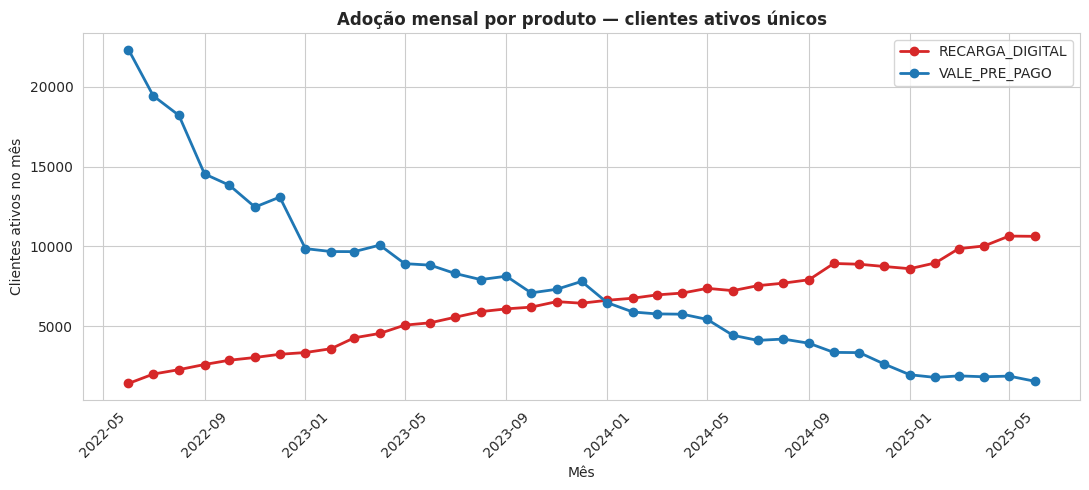

In [14]:
# 5.1 Gráfico: clientes ativos mensais por produto (proxy de adoção)
fig, ax = plt.subplots()
for prod, grp in evolucao.groupby('PRODUTO'):
    ax.plot(grp['MES_DT'], grp['clientes_ativos'], marker='o',
            label=prod, color=CORES.get(prod, 'gray'), linewidth=2)
ax.set_title('Adoção mensal por produto — clientes ativos únicos')
ax.set_xlabel('Mês'); ax.set_ylabel('Clientes ativos no mês')
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

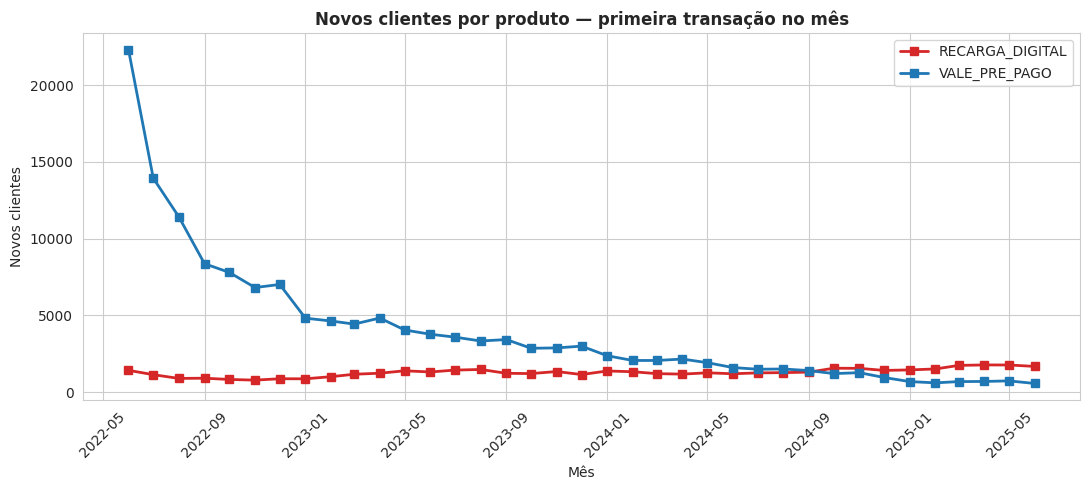

In [15]:
# 5.2 Gráfico: novos clientes por produto (entrada na base de cada produto)
fig, ax = plt.subplots()
for prod, grp in evolucao.groupby('PRODUTO'):
    ax.plot(grp['MES_DT'], grp['novos_clientes'], marker='s',
            label=prod, color=CORES.get(prod, 'gray'), linewidth=2)
ax.set_title('Novos clientes por produto — primeira transação no mês')
ax.set_xlabel('Mês'); ax.set_ylabel('Novos clientes')
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 6. Segmentação: nível, loja, cidade

Quais perfis usam mais cada produto? Onde está a maior oportunidade de migrar do Vale Pré-pago para a Recarga Digital?

In [16]:
# 6.1 Por NIVEL_CLIENTE — clientes ativos únicos em cada produto, por nível
perfil_nivel = (df.dropna(subset=['NIVEL_CLIENTE'])
                  .groupby(['NIVEL_CLIENTE', 'PRODUTO'])['ID_PESSOA']
                  .nunique().unstack(fill_value=0))
perfil_nivel['%_RD_no_nivel'] = (perfil_nivel.get('RECARGA_DIGITAL', 0) /
                                 perfil_nivel.sum(axis=1) * 100).round(1)
perfil_nivel

PRODUTO,RECARGA_DIGITAL,VALE_PRE_PAGO,%_RD_no_nivel
NIVEL_CLIENTE,,,
1,6280,9397,40.10
2,4082,8668,32.00
3,6571,18652,26.10
4,8798,32919,21.10
5,21639,77544,21.80


In [17]:
# 6.2 Por LOJA — top 10 lojas em volume de transações + share de Recarga Digital
perfil_loja = (df.groupby(['NUM_LOJA', 'PRODUTO']).size()
                 .unstack(fill_value=0))
perfil_loja['TOTAL'] = perfil_loja.sum(axis=1)
perfil_loja['%_RD'] = (perfil_loja.get('RECARGA_DIGITAL', 0) / perfil_loja['TOTAL'] * 100).round(1)
top_lojas = perfil_loja.sort_values('TOTAL', ascending=False).head(10)
top_lojas

PRODUTO,RECARGA_DIGITAL,VALE_PRE_PAGO,TOTAL,%_RD
NUM_LOJA,,,,
58.0,53408,47347,100755,53.00
59.0,43042,45161,88203,48.80
52.0,32453,38486,70939,45.70
55.0,30357,40080,70437,43.10
53.0,45343,22567,67910,66.80
61.0,41970,16123,58093,72.20
51.0,34894,20012,54906,63.60
250.0,40882,10098,50980,80.20
260.0,29286,19883,49169,59.60


In [18]:
# 6.3 Por CIDADE — top 10 cidades
perfil_cidade = (df.dropna(subset=['CIDADE'])
                   .groupby(['CIDADE', 'PRODUTO'])['ID_PESSOA']
                   .nunique().unstack(fill_value=0))
perfil_cidade['TOTAL_CLIENTES'] = perfil_cidade.sum(axis=1)
perfil_cidade['%_RD'] = (perfil_cidade.get('RECARGA_DIGITAL', 0) /
                         perfil_cidade['TOTAL_CLIENTES'] * 100).round(1)
top_cidades = perfil_cidade.sort_values('TOTAL_CLIENTES', ascending=False).head(10)
top_cidades

PRODUTO,RECARGA_DIGITAL,VALE_PRE_PAGO,TOTAL_CLIENTES,%_RD
CIDADE,,,,
MANAUS,38832,120679,159511,24.30
MANACAPURU,1870,8961,10831,17.30
ITACOATIARA,1521,6762,8283,18.40
IRANDUBA,2066,3494,5560,37.20
AUTAZES,1864,2960,4824,38.60
PRESIDENTE_FIGUEIREDO,873,3146,4019,21.70
DESCONHECIDO,20,65,85,23.50
RIO_BRANCO,21,63,84,25.00
NAO_INFORMADO,14,69,83,16.90


## 7. Visualizações comparativas e tabela-resumo

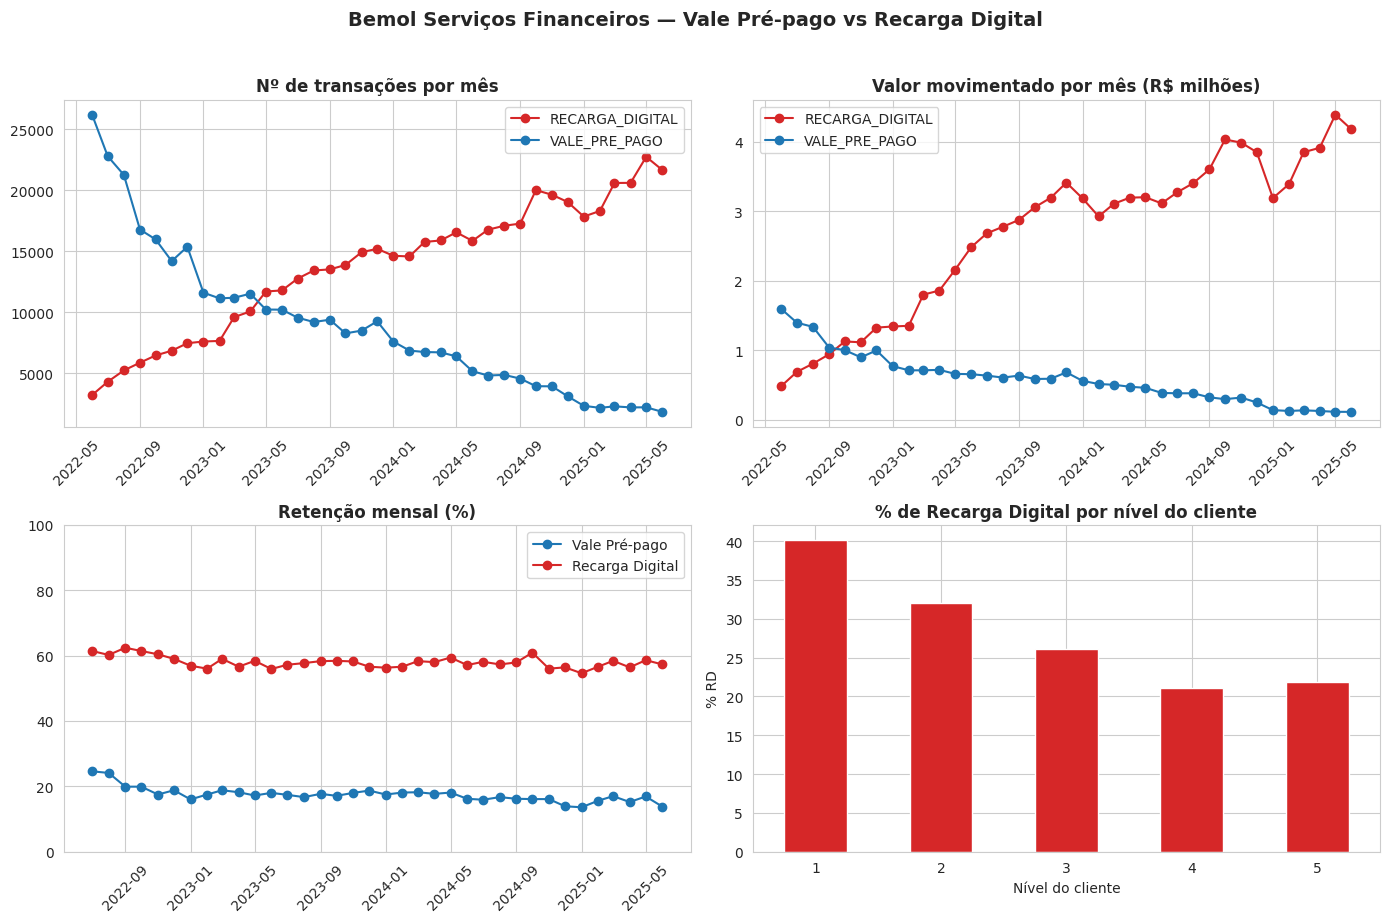

In [19]:
# 7.1 Gráfico comparativo principal: dashboard 2x2 com as 4 visões-chave
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Transações por mês
ax = axes[0, 0]
for prod, g in evolucao.groupby('PRODUTO'):
    ax.plot(g['MES_DT'], g['num_transacoes'], marker='o', label=prod, color=CORES.get(prod))
ax.set_title('Nº de transações por mês'); ax.legend(); ax.tick_params(axis='x', rotation=45)

# (b) Valor movimentado por mês
ax = axes[0, 1]
for prod, g in evolucao.groupby('PRODUTO'):
    ax.plot(g['MES_DT'], g['valor_total']/1e6, marker='o', label=prod, color=CORES.get(prod))
ax.set_title('Valor movimentado por mês (R$ milhões)'); ax.legend(); ax.tick_params(axis='x', rotation=45)

# (c) Retenção mensal
ax = axes[1, 0]
ax.plot(churn_vpp['MES'].dt.to_timestamp(), churn_vpp['retencao_%'],
        marker='o', color=CORES['VALE_PRE_PAGO'], label='Vale Pré-pago')
ax.plot(churn_rd['MES'].dt.to_timestamp(), churn_rd['retencao_%'],
        marker='o', color=CORES['RECARGA_DIGITAL'], label='Recarga Digital')
ax.set_title('Retenção mensal (%)'); ax.set_ylim(0, 100); ax.legend(); ax.tick_params(axis='x', rotation=45)

# (d) Share de Recarga Digital por nível de cliente
ax = axes[1, 1]
perfil_nivel['%_RD_no_nivel'].plot(kind='bar', ax=ax, color=CORES['RECARGA_DIGITAL'])
ax.set_title('% de Recarga Digital por nível do cliente')
ax.set_xlabel('Nível do cliente'); ax.set_ylabel('% RD'); ax.tick_params(axis='x', rotation=0)

plt.suptitle('Bemol Serviços Financeiros — Vale Pré-pago vs Recarga Digital',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [20]:
# 7.2 Tabela-resumo consolidada (entregável principal para a PM)
tabela_resumo = pd.DataFrame({
    'Vale Pré-pago': [
        int(metricas_produto.loc['VALE_PRE_PAGO', 'num_transacoes']),
        round(metricas_produto.loc['VALE_PRE_PAGO', 'valor_total'], 2),
        round(metricas_produto.loc['VALE_PRE_PAGO', 'ticket_medio'], 2),
        int(metricas_produto.loc['VALE_PRE_PAGO', 'clientes_unicos']),
        round(churn_vpp['retencao_%'].mean(), 1),
        round(churn_vpp['churn_%'].mean(), 1),
    ],
    'Recarga Digital': [
        int(metricas_produto.loc['RECARGA_DIGITAL', 'num_transacoes']),
        round(metricas_produto.loc['RECARGA_DIGITAL', 'valor_total'], 2),
        round(metricas_produto.loc['RECARGA_DIGITAL', 'ticket_medio'], 2),
        int(metricas_produto.loc['RECARGA_DIGITAL', 'clientes_unicos']),
        round(churn_rd['retencao_%'].mean(), 1),
        round(churn_rd['churn_%'].mean(), 1),
    ]
}, index=[
    'Nº de transações no período',
    'Valor total movimentado (R$)',
    'Ticket médio (R$)',
    'Clientes únicos',
    'Retenção média mensal (%)',
    'Churn médio mensal (%)'
])
tabela_resumo

,Vale Pré-pago,Recarga Digital
Nº de transações no período,"330,629.00","506,469.00"
Valor total movimentado (R$),"21,831,851.25","99,219,531.09"
Ticket médio (R$),66.03,195.90
Clientes únicos,"147,201.00","47,374.00"
Retenção média mensal (%),17.50,58.00
Churn médio mensal (%),82.50,42.00


## 8. Conclusões e recomendações para a PM

> *Os números abaixo devem ser preenchidos após rodar o notebook com os dados reais. Esta seção já está estruturada como roteiro do que olhar.*

**O que a tabela-resumo revela**
1. Comparar o **share de transações** e o **share de valor**: se a Recarga Digital tem ticket médio maior, ela pesa mais no valor do que no volume — sinal de uso mais sofisticado (PIX, contas).
2. **Retenção mensal**: o produto com maior retenção é o ecossistema que segura o cliente — provavelmente a Recarga Digital, pelas funcionalidades adicionais.
3. O **churn do Vale Pré-pago** é a janela mais clara para migração — esses clientes ainda estão na base e podem ser convertidos.

**O que os gráficos revelam**
- A **curva de adoção** (clientes ativos por mês) mostra se a Recarga Digital já cruzou o Vale Pré-pago ou ainda está crescendo abaixo.
- **Novos clientes por mês** indica se a aquisição da Recarga Digital está acelerando ou estagnada.
- O bloco de **% de Recarga Digital por nível** indica qual perfil já adota o produto digital — em geral, níveis mais altos adotam mais, o que sugere campanhas direcionadas aos níveis intermediários (2–3) com maior potencial não explorado.
- A **segmentação por loja e cidade** mostra onde concentrar esforço: lojas com alto volume de Vale Pré-pago e baixo share de Recarga Digital são os melhores candidatos a campanhas de migração presencial.

**Recomendações práticas para a PM**
1. **Campanha de migração** focada em clientes ativos de Vale Pré-pago dos últimos 90 dias, segmentada por nível 2 e 3 e pelas top 10 cidades de maior volume.
2. **Treinar lojas** com baixo share de Recarga Digital — usar as lojas com alto share como referência (playbook interno).
3. **Onboarding digital** para novos clientes: oferecer Recarga Digital como produto padrão e Vale Pré-pago apenas como fallback.
4. **Monitorar churn mensal** da Recarga Digital após a migração para garantir que o cliente migrado realmente fica ativo (não basta abrir; tem que transacionar).

---

### Uso de IA generativa neste case (desafio extra)
Usei IA generativa como copiloto para: (i) estruturar o roteiro do notebook a partir dos objetivos do PDF; (ii) revisar a função de cálculo de churn/retenção (mês-a-mês via conjuntos de clientes ativos); (iii) sugerir o layout do dashboard 2x2 que cobre as quatro perguntas-chave da PM em uma só figura. Todas as decisões de tratamento (remoção de negativos, manutenção de zeros, definição de cliente ativo) foram revisadas e validadas por mim antes de entrar no código.